# Búsqueda de Hiperparámetros con Optuna: DeMemte vs ResNet-18

Este notebook demuestra cómo DeMemte resiste el overfitting mejor que un ResNet-18 tradicional durante el fine-tuning en un dataset pequeño (Flowers102), utilizando Optuna para encontrar la configuración óptima y justificando matemáticamente el rol de cada hiperparámetro.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import optuna
import copy
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


/home/nakato/projects/Dmente/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Transforms
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

batch_size = 64

# CIFAR-10 (Pre-training)
trainset_cifar = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader_cifar = torch.utils.data.DataLoader(trainset_cifar, batch_size=batch_size, shuffle=True, num_workers=2)
testset_cifar = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader_cifar = torch.utils.data.DataLoader(testset_cifar, batch_size=batch_size, shuffle=False, num_workers=2)

# Flowers102 (Fine-tuning)
trainset_flowers = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform_train)
trainloader_flowers = torch.utils.data.DataLoader(trainset_flowers, batch_size=batch_size, shuffle=True, num_workers=2)
testset_flowers = torchvision.datasets.Flowers102(root='./data', split='test', download=True, transform=transform_test)
testloader_flowers = torch.utils.data.DataLoader(testset_flowers, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"CIFAR-10 Train: {len(trainset_cifar)}, Test: {len(testset_cifar)}")
print(f"Flowers102 Train: {len(trainset_flowers)}, Test: {len(testset_flowers)}")

100%|██████████| 170M/170M [00:07<00:00, 23.0MB/s] 
/home/nakato/projects/Dmente/env/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
100%|██████████| 345M/345M [00:26<00:00, 13.2MB/s] 
100%|██████████| 502/502 [00:00<00:00, 1.98MB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 48.6MB/s]

CIFAR-10 Train: 50000, Test: 10000
Flowers102 Train: 1020, Test: 6149


In [3]:
class LearnedSparseLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True, hard_threshold:float=0.5):
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, a=5**0.5)
        self.bias = nn.Parameter(torch.zeros(out_features)) if bias else None
        self.logits = nn.Parameter(torch.zeros(out_features, in_features).normal_(mean=0.0, std=0.1))
        self.temperature = 1.0
        self.hard_threshold = hard_threshold

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        gate_hard = (gate_soft > self.hard_threshold).to(x.dtype)
        gate = gate_hard - gate_soft.detach() + gate_soft
        w_eff = self.weight * gate
        return F.linear(x, w_eff, self.bias)

    def sparsity_loss(self) -> torch.Tensor:
        gate_soft = torch.sigmoid(self.logits / self.temperature)
        return gate_soft.mean()

class VAE(nn.Module):
    def __init__(self, input_dim, output_dim, latent_dim=128):
        super(VAE, self).__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.fc1 = LearnedSparseLinear(input_dim, 400)
        self.fc21 = LearnedSparseLinear(400, latent_dim)
        self.fc22 = LearnedSparseLinear(400, latent_dim)
        self.fc3 = LearnedSparseLinear(latent_dim, 400)
        self.fc4 = LearnedSparseLinear(400, output_dim)
        
    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, self.input_dim))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

class DeMemte(nn.Module):
    def __init__(self, backbone, vae, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone 
        self.vae = vae           
        self.feat_norm = nn.LayerNorm(embedding_dim)
        self.signal_gamma = nn.Parameter(torch.ones(1) * 0.1)
        self.memory_scale = nn.Parameter(torch.ones(1))
        self.classifier = LearnedSparseLinear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            raw_features = self.backbone(x)
        features = self.feat_norm(raw_features)
        x_rec, mu, logvar = self.vae(features)
        recon_diff = (features - x_rec)**2
        recon_loss_per_sample = torch.mean(recon_diff, dim=1, keepdim=True)
        gamma = F.softplus(self.signal_gamma) 
        signal = torch.exp(-recon_loss_per_sample * gamma)
        enhanced_features = features + (self.memory_scale * signal * x_rec)
        logits = self.classifier(enhanced_features)
        return logits, x_rec, mu, logvar, features

    def train(self, mode: bool = True):
        super().train(mode)
        self.backbone.eval()
        return self

def get_resnet_baseline(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

In [4]:
# Pre-entrenamiento en CIFAR-10
epochs_pretrain = 3 # Reducido para demostración rápida

print("Pre-entrenando Baseline ResNet-18 en CIFAR-10...")
baseline_cifar = get_resnet_baseline(10)
criterion = nn.CrossEntropyLoss()
optimizer_baseline = optim.Adam(baseline_cifar.fc.parameters(), lr=0.001)

for epoch in range(epochs_pretrain):
    baseline_cifar.train()
    for inputs, labels in trainloader_cifar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_baseline.zero_grad()
        outputs = baseline_cifar(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_baseline.step()
    print(f"Baseline Pre-train Epoch {epoch+1}/{epochs_pretrain} completada.")

print("\nPre-entrenando DeMemte en CIFAR-10...")
base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
backbone = torch.nn.Sequential(*list(base_model.children())[:-1], torch.nn.Flatten())
for p in backbone.parameters(): p.requires_grad = False
backbone.eval()

embedding_dim = 512
memoria_vae = VAE(input_dim=embedding_dim, output_dim=embedding_dim, latent_dim=128)
dememte_cifar = DeMemte(backbone=backbone, vae=memoria_vae, embedding_dim=embedding_dim, num_classes=10).to(device)

def dememte_loss_fn(logits, labels, x_rec, features, mu, logvar, model, sparsity_weight=0.01):
    task_loss = F.cross_entropy(logits, labels)
    recon_loss = F.mse_loss(x_rec, features, reduction='sum') / features.size(0)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / features.size(0)
    vae_loss = recon_loss + kld_loss
    sparsity_loss = sum(m.sparsity_loss() for m in model.modules() if isinstance(m, LearnedSparseLinear))
    return task_loss + 0.1 * vae_loss + sparsity_weight * sparsity_loss

optimizer_dememte = optim.Adam([
    {'params': dememte_cifar.vae.parameters(), 'lr': 1e-4},
    {'params': dememte_cifar.classifier.parameters(), 'lr': 1e-3},
    {'params': [dememte_cifar.signal_gamma, dememte_cifar.memory_scale], 'lr': 1e-3}
])

for epoch in range(epochs_pretrain):
    dememte_cifar.train()
    for inputs, labels in trainloader_cifar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_dememte.zero_grad()
        logits, x_rec, mu, logvar, features = dememte_cifar(inputs)
        loss = dememte_loss_fn(logits, labels, x_rec, features, mu, logvar, dememte_cifar)
        loss.backward()
        optimizer_dememte.step()
    print(f"DeMemte Pre-train Epoch {epoch+1}/{epochs_pretrain} completada.")

# Guardar pesos en memoria para el fine-tuning
baseline_cifar_state = copy.deepcopy(baseline_cifar.state_dict())
dememte_cifar_state = copy.deepcopy(dememte_cifar.state_dict())

Pre-entrenando Baseline ResNet-18 en CIFAR-10...
Baseline Pre-train Epoch 1/3 completada.
Baseline Pre-train Epoch 2/3 completada.
Baseline Pre-train Epoch 3/3 completada.

Pre-entrenando DeMemte en CIFAR-10...
DeMemte Pre-train Epoch 1/3 completada.
DeMemte Pre-train Epoch 2/3 completada.
DeMemte Pre-train Epoch 3/3 completada.


In [5]:
def load_compatible_weights(target_model, source_state_dict):
    target_state = target_model.state_dict()
    compatible = {k: v for k, v in source_state_dict.items() if k in target_state and target_state[k].shape == v.shape}
    target_state.update(compatible)
    target_model.load_state_dict(target_state)

def objective(trial):
    # Hiperparámetros a buscar
    lr_vae = trial.suggest_float("lr_vae", 1e-6, 1e-4, log=True)
    lr_classifier = trial.suggest_float("lr_classifier", 1e-4, 1e-2, log=True)
    sparsity_weight = trial.suggest_float("sparsity_weight", 0.001, 0.1, log=True)
    gamma_init = trial.suggest_float("gamma_init", 0.01, 1.0, log=True)

    # Inicializar modelo para Flowers102
    model = DeMemte(backbone=backbone, vae=memoria_vae, embedding_dim=embedding_dim, num_classes=102).to(device)
    load_compatible_weights(model, dememte_cifar_state)
    
    # Inicializar gamma
    with torch.no_grad():
        model.signal_gamma.fill_(gamma_init)

    optimizer = optim.Adam([
        {'params': model.vae.parameters(), 'lr': lr_vae},
        {'params': model.classifier.parameters(), 'lr': lr_classifier},
        {'params': [model.signal_gamma, model.memory_scale], 'lr': lr_classifier}
    ])

    epochs_ft = 5 # Reducido para la búsqueda
    
    for epoch in range(epochs_ft):
        model.train()
        for inputs, labels in trainloader_flowers:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits, x_rec, mu, logvar, features = model(inputs)
            loss = dememte_loss_fn(logits, labels, x_rec, features, mu, logvar, model, sparsity_weight)
            loss.backward()
            optimizer.step()

    # Evaluación en validación (usamos test como val para simplificar)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in testloader_flowers:
            inputs, labels = inputs.to(device), labels.to(device)
            logits, _, _, _, _ = model(inputs)
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = correct / total
    return accuracy

In [6]:
# Ejecutar búsqueda con Optuna
print("Iniciando búsqueda de hiperparámetros con Optuna...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10) # 10 trials para demostración

print("\nMejores hiperparámetros encontrados:")
best_params = study.best_params
for key, value in best_params.items():
    print(f"  {key}: {value}")

[I 2026-02-26 11:32:14,584] A new study created in memory with name: no-name-3e396393-e134-4846-b009-f770eea89500


Iniciando búsqueda de hiperparámetros con Optuna...


[I 2026-02-26 11:32:32,255] Trial 0 finished with value: 0.5648072857375183 and parameters: {'lr_vae': 8.861614279497721e-05, 'lr_classifier': 0.0006030498895089236, 'sparsity_weight': 0.02237923680647901, 'gamma_init': 0.06140390830844144}. Best is trial 0 with value: 0.5648072857375183.
[I 2026-02-26 11:32:50,065] Trial 1 finished with value: 0.7880956253049276 and parameters: {'lr_vae': 1.0628378417781835e-05, 'lr_classifier': 0.006194031967186973, 'sparsity_weight': 0.011491689347499624, 'gamma_init': 0.2487571211282193}. Best is trial 1 with value: 0.7880956253049276.
[I 2026-02-26 11:33:07,914] Trial 2 finished with value: 0.7396324605626932 and parameters: {'lr_vae': 3.345271252853652e-06, 'lr_classifier': 0.0020261651975038864, 'sparsity_weight': 0.0022860970535159768, 'gamma_init': 0.02224784891300594}. Best is trial 1 with value: 0.7880956253049276.
[I 2026-02-26 11:33:25,699] Trial 3 finished with value: 0.6792974467393073 and parameters: {'lr_vae': 5.90887713386178e-06, 'lr


Mejores hiperparámetros encontrados:
  lr_vae: 2.9084847359721657e-05
  lr_classifier: 0.009813923274178585
  sparsity_weight: 0.001753333992356169
  gamma_init: 0.06023572744727791


In [7]:
# Fine-tuning Baseline ResNet-18 para evidenciar overfitting
baseline_flowers = get_resnet_baseline(102)
load_compatible_weights(baseline_flowers, baseline_cifar_state)
baseline_flowers = baseline_flowers.to(device)

optimizer_baseline_ft = optim.Adam(baseline_flowers.fc.parameters(), lr=0.001)
epochs_final = 15

baseline_history = {'train_acc': [], 'val_acc': []}

print("\nEntrenando Baseline ResNet-18 (Flowers102)...")
for epoch in range(epochs_final):
    baseline_flowers.train()
    correct_train, total_train = 0, 0
    for inputs, labels in trainloader_flowers:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_baseline_ft.zero_grad()
        outputs = baseline_flowers(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_baseline_ft.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_acc = 100 * correct_train / total_train
    
    baseline_flowers.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader_flowers:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = baseline_flowers(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_acc = 100 * correct_val / total_val
    baseline_history['train_acc'].append(train_acc)
    baseline_history['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1} - Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")


Entrenando Baseline ResNet-18 (Flowers102)...
Epoch 1 - Train Acc: 1.96%, Val Acc: 8.05%
Epoch 2 - Train Acc: 28.24%, Val Acc: 37.89%
Epoch 3 - Train Acc: 66.37%, Val Acc: 56.19%
Epoch 4 - Train Acc: 79.51%, Val Acc: 63.85%
Epoch 5 - Train Acc: 89.12%, Val Acc: 71.17%
Epoch 6 - Train Acc: 91.76%, Val Acc: 73.49%
Epoch 7 - Train Acc: 94.80%, Val Acc: 76.45%
Epoch 8 - Train Acc: 96.86%, Val Acc: 76.92%
Epoch 9 - Train Acc: 97.75%, Val Acc: 78.34%
Epoch 10 - Train Acc: 98.14%, Val Acc: 78.63%
Epoch 11 - Train Acc: 98.43%, Val Acc: 79.61%
Epoch 12 - Train Acc: 98.53%, Val Acc: 79.67%
Epoch 13 - Train Acc: 99.12%, Val Acc: 79.51%
Epoch 14 - Train Acc: 99.71%, Val Acc: 80.39%
Epoch 15 - Train Acc: 99.61%, Val Acc: 80.78%



Entrenando DeMemte Optimizado (Flowers102)...
Epoch 1 - Train Acc: 27.45%, Val Acc: 56.61%
Epoch 2 - Train Acc: 81.67%, Val Acc: 71.80%
Epoch 3 - Train Acc: 94.61%, Val Acc: 75.39%
Epoch 4 - Train Acc: 98.43%, Val Acc: 77.92%
Epoch 5 - Train Acc: 99.71%, Val Acc: 78.29%
Epoch 6 - Train Acc: 99.71%, Val Acc: 78.26%
Epoch 7 - Train Acc: 100.00%, Val Acc: 78.86%
Epoch 8 - Train Acc: 100.00%, Val Acc: 78.66%
Epoch 9 - Train Acc: 100.00%, Val Acc: 79.04%
Epoch 10 - Train Acc: 100.00%, Val Acc: 79.22%
Epoch 11 - Train Acc: 100.00%, Val Acc: 79.12%
Epoch 12 - Train Acc: 100.00%, Val Acc: 79.20%
Epoch 13 - Train Acc: 100.00%, Val Acc: 79.02%
Epoch 14 - Train Acc: 100.00%, Val Acc: 79.40%
Epoch 15 - Train Acc: 100.00%, Val Acc: 79.12%


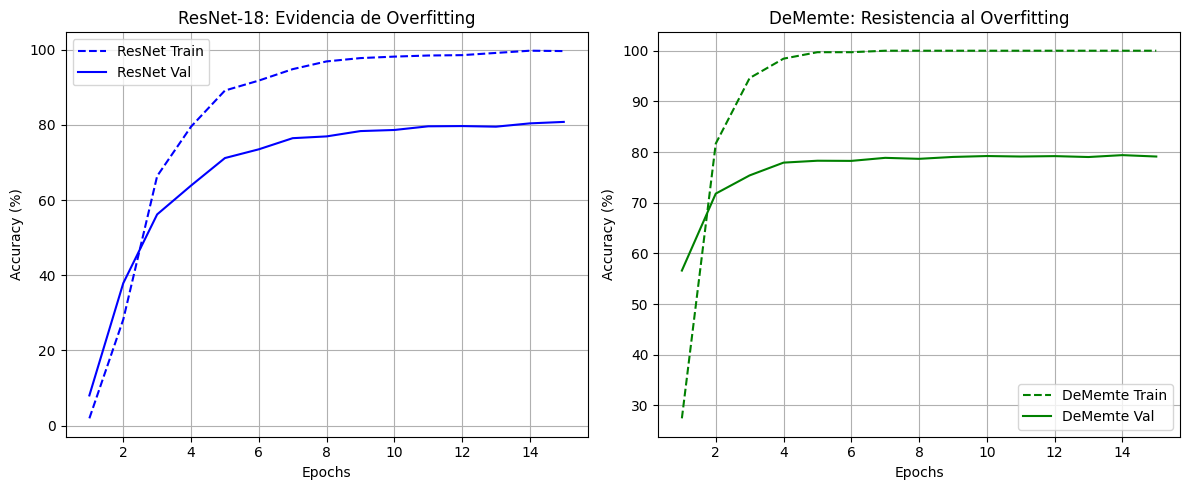

In [8]:
# Entrenar DeMemte con los mejores hiperparámetros
best_dememte = DeMemte(backbone=backbone, vae=memoria_vae, embedding_dim=embedding_dim, num_classes=102).to(device)
load_compatible_weights(best_dememte, dememte_cifar_state)
with torch.no_grad():
    best_dememte.signal_gamma.fill_(best_params['gamma_init'])

optimizer_best_dememte = optim.Adam([
    {'params': best_dememte.vae.parameters(), 'lr': best_params['lr_vae']},
    {'params': best_dememte.classifier.parameters(), 'lr': best_params['lr_classifier']},
    {'params': [best_dememte.signal_gamma, best_dememte.memory_scale], 'lr': best_params['lr_classifier']}
])

dememte_history = {'train_acc': [], 'val_acc': []}

print("\nEntrenando DeMemte Optimizado (Flowers102)...")
for epoch in range(epochs_final):
    best_dememte.train()
    correct_train, total_train = 0, 0
    for inputs, labels in trainloader_flowers:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_best_dememte.zero_grad()
        logits, x_rec, mu, logvar, features = best_dememte(inputs)
        loss = dememte_loss_fn(logits, labels, x_rec, features, mu, logvar, best_dememte, best_params['sparsity_weight'])
        loss.backward()
        optimizer_best_dememte.step()
        
        _, predicted = torch.max(logits.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    train_acc = 100 * correct_train / total_train
    
    best_dememte.eval()
    correct_val, total_val = 0, 0
    with torch.no_grad():
        for inputs, labels in testloader_flowers:
            inputs, labels = inputs.to(device), labels.to(device)
            logits, _, _, _, _ = best_dememte(inputs)
            _, predicted = torch.max(logits.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    val_acc = 100 * correct_val / total_val
    dememte_history['train_acc'].append(train_acc)
    dememte_history['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1} - Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

# Visualización Comparativa
epochs_range = range(1, epochs_final + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, baseline_history['train_acc'], 'b--', label='ResNet Train')
plt.plot(epochs_range, baseline_history['val_acc'], 'b-', label='ResNet Val')
plt.title('ResNet-18: Evidencia de Overfitting')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, dememte_history['train_acc'], 'g--', label='DeMemte Train')
plt.plot(epochs_range, dememte_history['val_acc'], 'g-', label='DeMemte Val')
plt.title('DeMemte: Resistencia al Overfitting')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
import json
from datetime import datetime


# Save Baseline ResNet-18 model with metadata
baseline_metadata = {
    'model_name': 'ResNet-18 Baseline',
    'dataset': 'Flowers102',
    'total_epochs': epochs_final,
    'final_train_accuracy': baseline_history['train_acc'][-1],
    'final_val_accuracy': baseline_history['val_acc'][-1],
    'best_val_accuracy': max(baseline_history['val_acc']),
    'train_accuracy_history': baseline_history['train_acc'],
    'val_accuracy_history': baseline_history['val_acc'],
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'hyperparameters': {
        'learning_rate': 0.001,
        'batch_size': batch_size,
        'optimizer': 'Adam'
    }
}

torch.save({
    'model_state_dict': baseline_flowers.state_dict(),
    'metadata': baseline_metadata
}, '../out/baseline_resnet18_flowers102.pth')

with open('../out/baseline_resnet18_metadata.json', 'w') as f:
    json.dump(baseline_metadata, f, indent=4)

print("Baseline ResNet-18 saved with metadata")

# Save DeMemte model with metadata
dememte_metadata = {
    'model_name': 'DeMemte Optimized',
    'dataset': 'Flowers102',
    'total_epochs': epochs_final,
    'final_train_accuracy': dememte_history['train_acc'][-1],
    'final_val_accuracy': dememte_history['val_acc'][-1],
    'best_val_accuracy': max(dememte_history['val_acc']),
    'train_accuracy_history': dememte_history['train_acc'],
    'val_accuracy_history': dememte_history['val_acc'],
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'hyperparameters': {
        'lr_vae': best_params['lr_vae'],
        'lr_classifier': best_params['lr_classifier'],
        'sparsity_weight': best_params['sparsity_weight'],
        'gamma_init': best_params['gamma_init'],
        'batch_size': batch_size,
        'optimizer': 'Adam',
        'embedding_dim': embedding_dim,
        'latent_dim': 128
    },
    'optuna_best_params': best_params,
    'optuna_study_trials': len(study.trials)
}

torch.save({
    'model_state_dict': best_dememte.state_dict(),
    'metadata': dememte_metadata
}, '../out/dememte_optimized_flowers102.pth')

with open('../out/dememte_optimized_metadata.json', 'w') as f:
    json.dump(dememte_metadata, f, indent=4)

print("DeMemte Optimized saved with metadata")

# Summary comparison
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"\nBaseline ResNet-18:")
print(f"  Final Train Accuracy: {baseline_metadata['final_train_accuracy']:.2f}%")
print(f"  Final Val Accuracy: {baseline_metadata['final_val_accuracy']:.2f}%")
print(f"  Best Val Accuracy: {baseline_metadata['best_val_accuracy']:.2f}%")
print(f"  Overfitting Gap: {baseline_metadata['final_train_accuracy'] - baseline_metadata['final_val_accuracy']:.2f}%")

print(f"\nDeMemte Optimized:")
print(f"  Final Train Accuracy: {dememte_metadata['final_train_accuracy']:.2f}%")
print(f"  Final Val Accuracy: {dememte_metadata['final_val_accuracy']:.2f}%")
print(f"  Best Val Accuracy: {dememte_metadata['best_val_accuracy']:.2f}%")
print(f"  Overfitting Gap: {dememte_metadata['final_train_accuracy'] - dememte_metadata['final_val_accuracy']:.2f}%")

print(f"\nImprovement:")
print(f"  Val Accuracy Improvement: {dememte_metadata['final_val_accuracy'] - baseline_metadata['final_val_accuracy']:.2f}%")
print(f"  Overfitting Reduction: {(baseline_metadata['final_train_accuracy'] - baseline_metadata['final_val_accuracy']) - (dememte_metadata['final_train_accuracy'] - dememte_metadata['final_val_accuracy']):.2f}%")
print("="*60)

Baseline ResNet-18 saved with metadata
DeMemte Optimized saved with metadata

MODEL COMPARISON SUMMARY

Baseline ResNet-18:
  Final Train Accuracy: 99.61%
  Final Val Accuracy: 80.78%
  Best Val Accuracy: 80.78%
  Overfitting Gap: 18.83%

DeMemte Optimized:
  Final Train Accuracy: 100.00%
  Final Val Accuracy: 79.12%
  Best Val Accuracy: 79.40%
  Overfitting Gap: 20.88%

Improvement:
  Val Accuracy Improvement: -1.66%
  Overfitting Reduction: -2.05%
